In [7]:
# =========================================================
# IMPORTS
# =========================================================
import os
import torch
import numpy as np
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

# =========================================================
# DEVICE SETUP
# =========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Using CPU")

# =========================================================
# DATA TRANSFORMS
# =========================================================
IMG_SIZE = 256
transform_img = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

transform_mask = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=Image.NEAREST),
    transforms.ToTensor(),
])

# =========================================================
# DATASET CLASS
# =========================================================
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform_img=None, transform_mask=None):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.transform_img = transform_img
        self.transform_mask = transform_mask
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(".jpg")])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_name = self.images[idx]
        image_path = self.img_dir / image_name
        mask_name = image_name.replace(".jpg", "_mask.png")
        mask_path = self.mask_dir / mask_name

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform_img:
            image = self.transform_img(image)
        if self.transform_mask:
            mask = self.transform_mask(mask)

        mask = (mask > 0.5).float()
        return image, mask

✅ Using GPU: NVIDIA GeForce RTX 5080


In [8]:
# =========================================================
# MODEL LOADING
# =========================================================
try:
    base_path = Path(__file__).parent  # 若在 .py 文件运行
except NameError:
    base_path = Path(os.getcwd())      # 若在 Jupyter Notebook 运行

MODEL_DIR = base_path / "models"

model_files = [f for f in os.listdir(MODEL_DIR) if f.endswith(".pth")]
if not model_files:
    raise FileNotFoundError(f"No .pth files found in {MODEL_DIR}")

print("Available models:")
for i, f in enumerate(model_files):
    print(f"  [{i}] {f}")

choice = int(input("\nSelect a model number to load: "))
model_name = model_files[choice]
model_path = MODEL_DIR / model_name

# 判断模型结构
if "++" in model_name:
    model_class = smp.UnetPlusPlus
else:
    model_class = smp.Unet

# 判断encoder
if "vgg16" in model_name:
    encoder = "vgg16"
elif "res50" in model_name:
    encoder = "resnet50"
elif "xception" in model_name.lower():
    encoder = "xception"
else:
    encoder = "resnet34"

print(f"\n📦 Loading model: {model_name}")
model = model_class(
    encoder_name=encoder,
    encoder_weights=None,
    in_channels=3,
    classes=1,
).to(DEVICE)

state_dict = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
print("✅ Model loaded successfully!\n")





Available models:
  [0] res50_unet++_aa_de.pth
  [1] res50_unet++_aa_en.pth
  [2] res50_unet++_ba_de.pth
  [3] res50_unet++_ba_en.pth
  [4] res50_unet_aa_de.pth
  [5] res50_unet_aa_en.pth
  [6] res50_unet_ba_de.pth
  [7] res50_unet_ba_en.pth
  [8] vgg16_unet++_aa_de.pth
  [9] vgg16_unet++_aa_en.pth
  [10] vgg16_unet++_ba_de.pth
  [11] vgg16_unet++_ba_en.pth
  [12] vgg16_unet_aa_de.pth
  [13] vgg16_unet_aa_en.pth
  [14] vgg16_unet_ba_de.pth
  [15] vgg16_unet_ba_en.pth
  [16] Xception_unet++_aa_de.pth
  [17] Xception_unet++_aa_en.pth
  [18] Xception_unet++_ba_de.pth
  [19] Xception_unet++_ba_en.pth
  [20] Xception_unet_aa_de.pth
  [21] Xception_unet_aa_en.pth
  [22] Xception_unet_ba_de.pth
  [23] Xception_unet_ba_en.pth

📦 Loading model: res50_unet++_aa_de.pth
✅ Model loaded successfully!



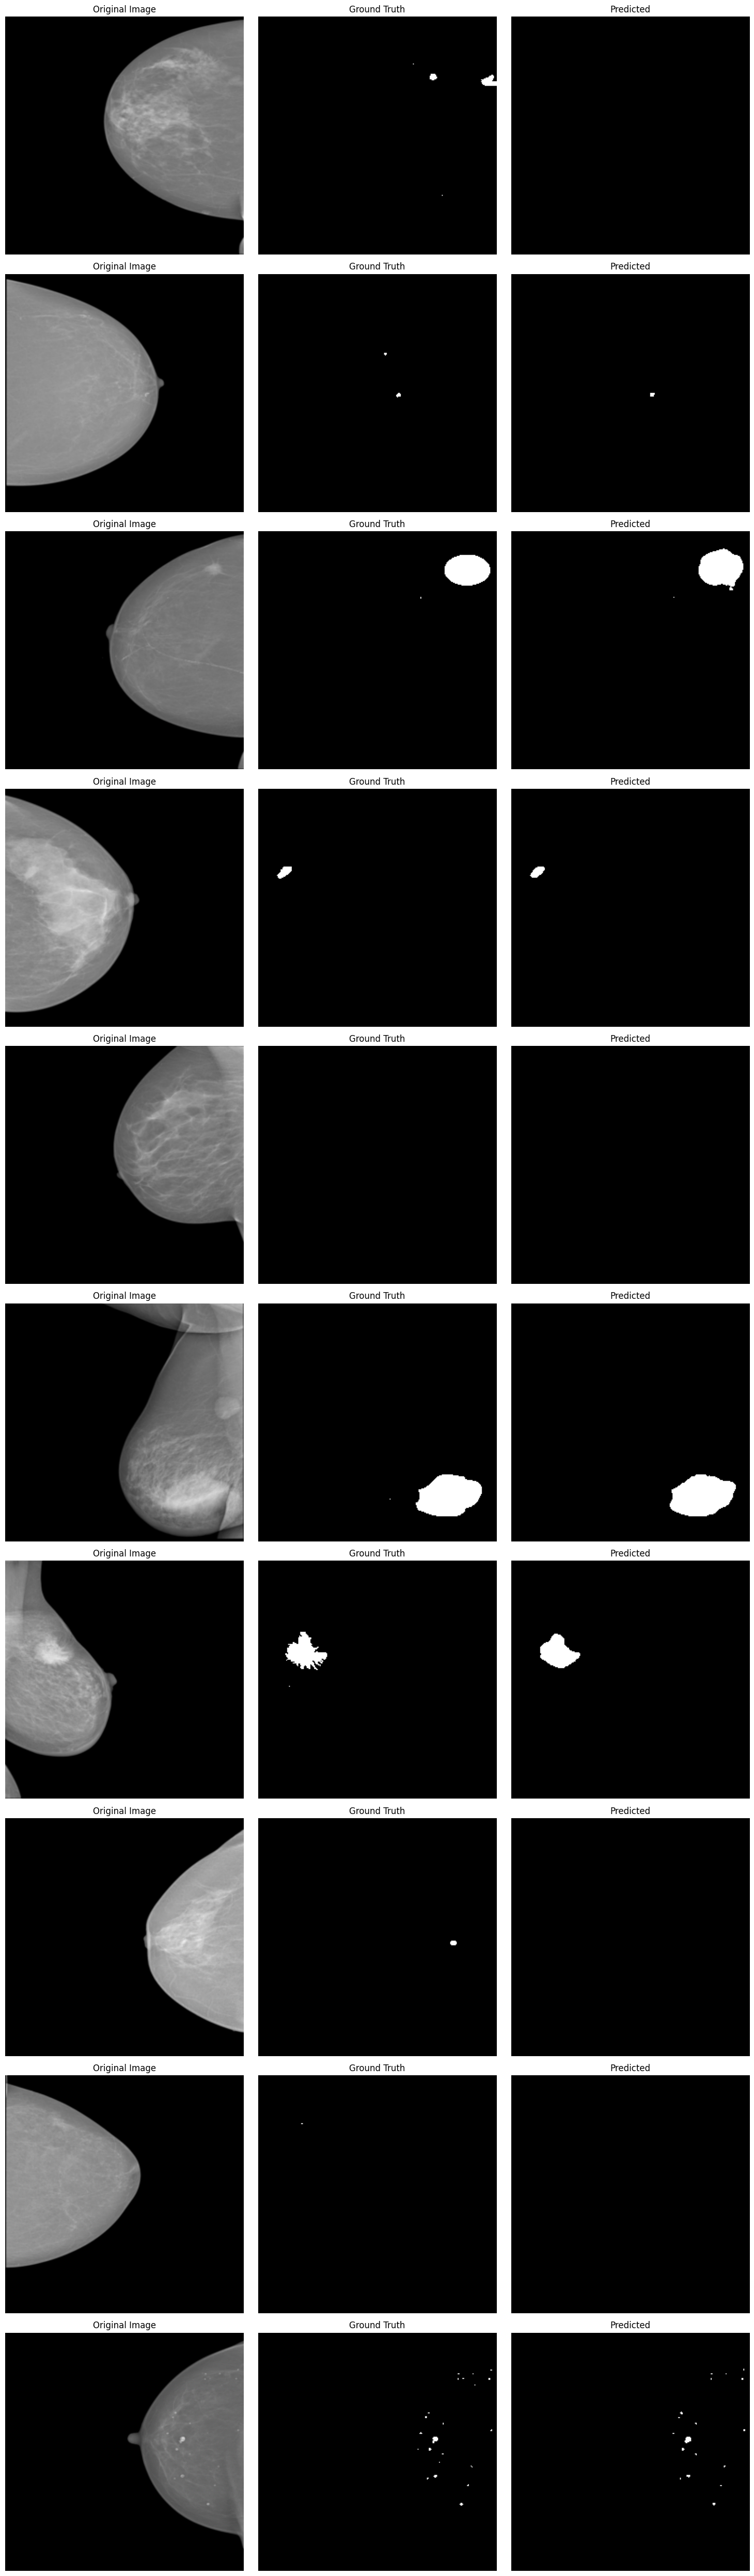

In [10]:
# =========================================================
# DATA LOADING
# =========================================================
base_dir = Path(r"D:\OneDrive\OneDrive - Rose-Hulman Institute of Technology\Rose-Hulman\course\CSSE\CSSE416\dataset_Unet")
test_img_dir = base_dir / "test" / "images"
test_mask_dir = base_dir / "test" / "labels"
test_ds = SegDataset(test_img_dir, test_mask_dir, transform_img, transform_mask)

# =========================================================
# HELPER FUNCTION
# =========================================================
def unnormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    tensor = tensor.cpu().numpy().transpose(1, 2, 0)
    tensor = (tensor * std + mean)
    tensor = np.clip(tensor, 0, 1)
    return tensor

# =========================================================
# VISUALIZATION
# =========================================================
num_show = 10  # 想显示几张就改这个数字
plt.figure(figsize=(15, 5 * num_show))

for idx in range(num_show):
    img, mask = test_ds[idx]
    img_tensor = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float().cpu().squeeze().numpy()

    img_np = unnormalize(img)
    mask_np = mask.cpu().squeeze().numpy()

    plt.subplot(num_show, 3, idx * 3 + 1)
    plt.imshow(img_np)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(num_show, 3, idx * 3 + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_show, 3, idx * 3 + 3)
    plt.imshow(pred, cmap="gray")
    plt.title("Predicted")
    plt.axis("off")

plt.tight_layout()
plt.show()